# Code for reproducing Figure 2 plots
## This notebooks depend on first generating the processed and clustered data

last updated: 20241202

## Import data and functions

In [1]:
import scanpy as sc
import pandas as pd
import anndata
import os
import re
import numpy as np
import scipy
import seaborn
import bbknn
import matplotlib
import matplotlib.pyplot as plt


/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# set a path to your working directory
directory='/Set/your/path/'

# load .h5ad with processed data 
adata = sc.read_h5ad(directory+'/Written_files/D40-100_GEX_processed-clustered.h5ad')

print(adata)

AnnData object with n_obs × n_vars = 105777 × 51861
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'species', 'pool_type', 'time_point', 'experiment', 'day_10x', 'lane', 'n_genes', 'percent_mito', 'percent_ribo', 'n_counts', 'leiden'
    var: 'gene_ids-D100_M_0-4_Chimp', 'feature_types-D100_M_0-4_Chimp', 'genome-D100_M_0-4_Chimp', 'gene_ids-D100_M_0-4_Human', 'feature_types-D100_M_0-4_Human', 'genome-D100_M_0-4_Human', 'gene_ids-D100_M_0-4_Rhesus', 'feature_types-D100_M_0-4_Rhesus', 'genome-D100_M_0-4_Rhesus', 'gene_ids-D100_M_0-5_Chimp', 'feature_types-D100_M_0-5_Chimp', 'genome-D100_M_0-5_Chimp', 'gene_ids-D100_M_0-5_Human', 'feature_types-D100_M_0-5_Human', 'genome-D100_M_0-5_Human', 'gene_ids-D100_M_0-5_Rhesus', 'feature_types-D100_M_0-5_Rhesus', 'genome-D100_M_0-5_Rhesus', 'gene_ids-D100_M_0-6_Chimp', 'feature_types-D100_M_0-6_Chimp', 'genome-D100_M_0-6_Chimp', 'gene_ids-D100_M_0-6_Human', 'feature_types-D100_M_0-

# Figure panel 2C

Proportions of all individuals at D40, 80 and 100, post quality control and doublet removal.

In [3]:
# Create obs species_individual
species_individual = pd.Categorical(adata.obs['species'].astype(str) + ('_') + adata.obs['individual'].astype(str))
adata.obs['species_individual'] = species_individual

<Figure size 432x288 with 0 Axes>

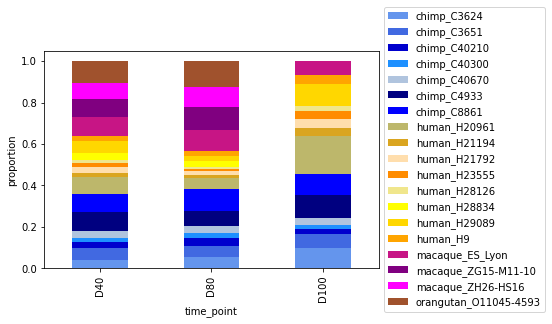

In [4]:
# only plot cells with assigned identity
adata_D40_100_proportion = adata[~adata.obs['species_individual'].isin(['chimp_nan','human_nan', 'macaque_nan'])]

# Set color scheme
custom_colors = {
    'chimp_C3624': 'cornflowerblue',
    'chimp_C3651': 'royalblue',
    'chimp_C4933': 'navy',
    'chimp_C8861': 'blue',
    'chimp_C40210': 'mediumblue',
    'chimp_C40300': 'dodgerblue',
    'chimp_C40670': 'lightsteelblue',
    'human_H9': 'orange',
    'human_H20961': 'darkkhaki',
    'human_H21194': 'goldenrod',
    'human_H21792': 'navajowhite',
    'human_H23555': 'darkorange',
    'human_H28126': 'khaki',
    'human_H28834': 'yellow',
    'human_H29089': 'gold',
    'macaque_ZG15-M11-10': 'purple',
    'macaque_ES_Lyon': 'mediumvioletred',
    'macaque_ZH26-HS16': 'magenta',
    'orangutan_O11045-4593': 'sienna',
}


f = plt.figure()
df_plot = adata_D40_100_proportion.obs.groupby(['species_individual', 'time_point']).size().reset_index().pivot(columns='species_individual', index='time_point', values=0).apply(lambda g: g / g.sum(), 1)

# Extract individual names from the columns
individuals = df_plot.columns

# Create a list of colors based on the custom_colors dictionary
colors = [custom_colors.get(individual, None) for individual in individuals]

# Filter out None values (default_color) from the list
colors = [color for color in colors if color is not None]

ax=df_plot.plot(kind='bar', stacked=True, color=colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('proportion')

plt.show()

# Figure panel 2D

UMAPs of cells collected at D40-100, colored by species.

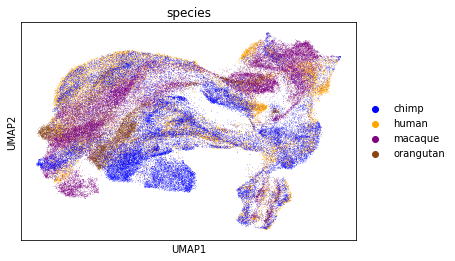

In [5]:
# set species colors
adata.uns['species_colors'] = ['blue','orange', 'purple','saddlebrown']
species_colors = adata.uns['species_colors'] 

# color UMAP based on species
sc.pl.umap(adata, color='species', save='_D40-100_species.png')

# Figure panel 2E

UMAPs of cells collected at D40-100, colored by time point.

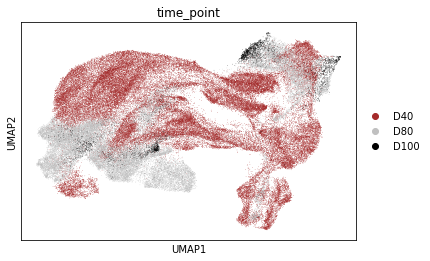

In [6]:
# set time point colors
adata.uns['time_point_colors'] = ['brown','silver', 'black']
time_point_colors = adata.uns["time_point_colors"] 

# color UMAP based on species
sc.pl.umap(adata, color='time_point', save='_D40-100_timepoint.png')

# Figure panel 2F

UMAPs of cells collected at D40-100, colored by assigned cell type identity.

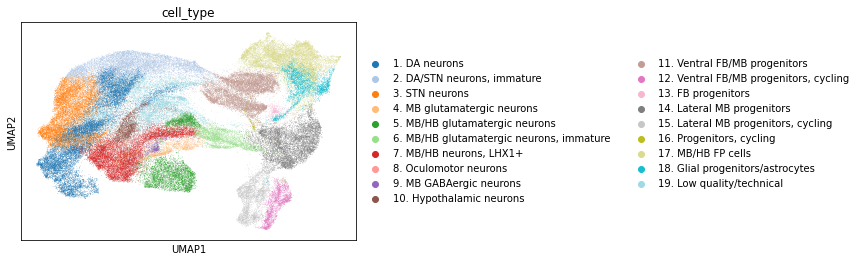

In [5]:
# assign cell type names to each of the leiden clusters

labeldict={'0':'7. MB/HB neurons, LHX1+',
           '1':'3. STN neurons',
           '2':'1. DA neurons',
           '3':'2. DA/STN neurons, immature',
           '4':'17. MB/HB FP cells',
           '5':'11. Ventral FB/MB progenitors',
           '6':'1. DA neurons',
           '7':'11. Ventral FB/MB progenitors',
           '8':'3. STN neurons',
           '9':'17. MB/HB FP cells',
           '10':'19. Low quality/technical',
           '11':'5. MB/HB glutamatergic neurons',
           '12':'14. Lateral MB progenitors',
           '13':'1. DA neurons',
           '14':'15. Lateral MB progenitors, cycling',
           '15':'18. Glial progenitors/astrocytes',
           '16':'14. Lateral MB progenitors',
           '17':'6. MB/HB glutamatergic neurons, immature',
           '18':'2. DA/STN neurons, immature',
           '19':'7. MB/HB neurons, LHX1+',
           '20':'10. Hypothalamic neurons',
           '21':'12. Ventral FB/MB progenitors, cycling',
           '22':'19. Low quality/technical',
           '23':'4. MB glutamatergic neurons',
           '24':'19. Low quality/technical',
           '25':'5. MB/HB glutamatergic neurons',
           '26':'9. MB GABAergic neurons',
           '27':'13. FB progenitors',
           '28':'8. Oculomotor neurons',
           '29':'16. Progenitors, cycling'
           }

adata.obs['cell_type']=[labeldict[x] for x in adata.obs['leiden']]

# color UMAP based on assigned cell type
sc.pl.umap(adata, color=['cell_type'], palette='tab20', save='_D40-100_celltype.png')

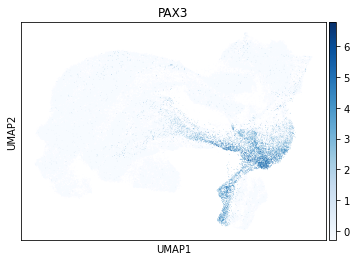

In [8]:
sc.pl.umap(adata,color='PAX3',use_raw=False, palette="Set2", color_map=matplotlib.cm.Blues)

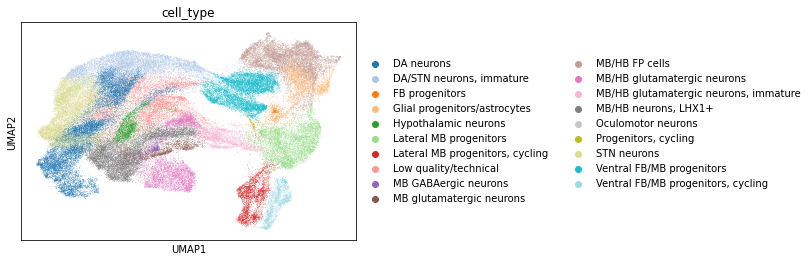

In [6]:
# assign cell type names to each of the leiden clusters

labeldict={'0':'MB/HB neurons, LHX1+',
           '1':'STN neurons',
           '2':'DA neurons',
           '3':'DA/STN neurons, immature',
           '4':'MB/HB FP cells',
           '5':'Ventral FB/MB progenitors',
           '6':'DA neurons',
           '7':'Ventral FB/MB progenitors',
           '8':'STN neurons',
           '9':'MB/HB FP cells',
           '10':'Low quality/technical',
           '11':'MB/HB glutamatergic neurons',
           '12':'Lateral MB progenitors',
           '13':'DA neurons',
           '14':'Lateral MB progenitors, cycling',
           '15':'Glial progenitors/astrocytes',
           '16':'Lateral MB progenitors',
           '17':'MB/HB glutamatergic neurons, immature',
           '18':'DA/STN neurons, immature',
           '19':'MB/HB neurons, LHX1+',
           '20':'Hypothalamic neurons',
           '21':'Ventral FB/MB progenitors, cycling',
           '22':'Low quality/technical',
           '23':'MB glutamatergic neurons',
           '24':'Low quality/technical',
           '25':'MB/HB glutamatergic neurons',
           '26':'MB GABAergic neurons',
           '27':'FB progenitors',
           '28':'Oculomotor neurons',
           '29':'Progenitors, cycling'
           }

adata.obs['cell_type']=[labeldict[x] for x in adata.obs['leiden']]

# color UMAP based on assigned cell type
sc.pl.umap(adata, color=['cell_type'], palette='tab20', save='_D40-100_celltype.png')

# Figure panel 2G

Dotplot of the expression of cell type markers for the assigned cluster identities at D40-100 and bar chart of the contribution of individuals to the different cell types

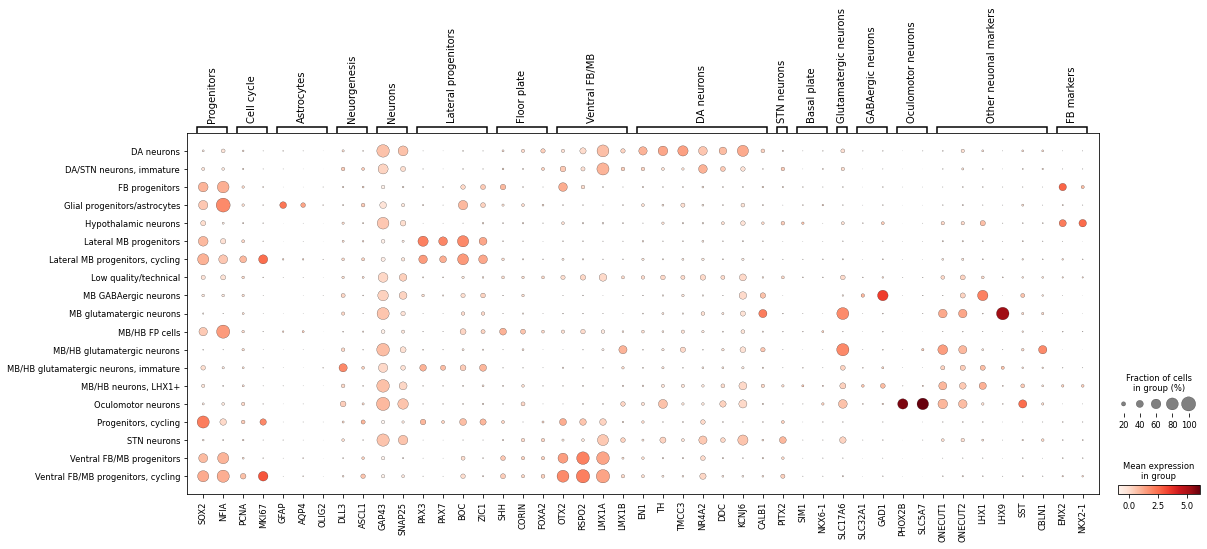

In [7]:
# Generate a dotplot of marker gene expression in the assigned cell types
summary_markers = {
    'Progenitors':['SOX2', 'NFIA'],
    'Cell cycle': ['PCNA', 'MKI67'],
    'Astrocytes' :['GFAP', 'AQP4', 'OLIG2'],
    'Neuorgenesis':['DLL3', 'ASCL1'],
    'Neurons':['GAP43', 'SNAP25'],
    'Lateral progenitors':['PAX3', 'PAX7', 'BOC', 'ZIC1'],
    'Floor plate':['SHH','CORIN', 'FOXA2'],
    'Ventral FB/MB': ['OTX2','RSPO2', 'LMX1A','LMX1B'],
    'DA neurons': ['EN1','TH','TMCC3','NR4A2','DDC','KCNJ6','CALB1' ],
    'STN neurons':['PITX2'], 
    'Basal plate': ['SIM1','NKX6-1'],
    'Glutamatergic neurons': ['SLC17A6'],
    'GABAergic neurons': ['SLC32A1','GAD1'],
    'Oculomotor neurons':['PHOX2B','SLC5A7'],
    'Other neuonal markers': ['ONECUT1','ONECUT2','LHX1', 'LHX9','SST', 'CBLN1'],
    'FB markers': ['EMX2','NKX2-1']
                
}

sc.pl.dotplot(adata, summary_markers, use_raw=False,  groupby='cell_type', save='_D40-100_markergenes.pdf')

/var/folders/3f/qnn57wjj4f330myjp0cbvc780000gp/T/ipykernel_4109/264259760.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_D40_100_proportion.obs['cell_type']=[labeldict[x] for x in adata_D40_100_proportion.obs['leiden']]


<Figure size 432x288 with 0 Axes>

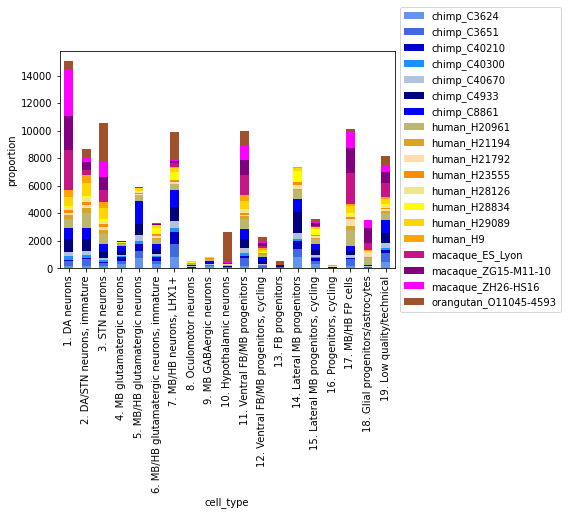

In [14]:
# Add celltype names to adata_D40-100_proportion object
adata_D40_100_proportion.obs['cell_type']=[labeldict[x] for x in adata_D40_100_proportion.obs['leiden']]

f = plt.figure()
df_plot = adata_D40_100_proportion.obs.groupby(['species_individual', 'cell_type']).size().reset_index().pivot(columns='species_individual', index='cell_type', values=0)

# Define the custom order for cell types
ordered_cell_types = ['1. DA neurons', '2. DA/STN neurons, immature','3. STN neurons','4. MB glutamatergic neurons',
                     '5. MB/HB glutamatergic neurons','6. MB/HB glutamatergic neurons, immature','7. MB/HB neurons, LHX1+',
                     '8. Oculomotor neurons','9. MB GABAergic neurons','10. Hypothalamic neurons','11. Ventral FB/MB progenitors',
                     '12. Ventral FB/MB progenitors, cycling','13. FB progenitors','14. Lateral MB progenitors',
                     '15. Lateral MB progenitors, cycling','16. Progenitors, cycling','17. MB/HB FP cells','18. Glial progenitors/astrocytes',
                     '19. Low quality/technical',] 

# Reorder the rows of df_plot based on the custom order
df_plot = df_plot.reindex(ordered_cell_types)

# Extract individual names from the columns
individuals = df_plot.columns

# Create a list of colors based on the custom_colors dictionary
colors = [custom_colors.get(individual, None) for individual in individuals]

# Filter out None values (default_color) from the list
colors = [color for color in colors if color is not None]

ax = df_plot.plot(kind='bar', stacked=True, color=colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('proportion')

plt.show()